In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
def shulie(shuzi,suoyin):
    mylist=list(range(-1*(shuzi//2), 1*(shuzi//2)+1))
    if mylist[suoyin]>0 and mylist[suoyin]%2==1:
        return -1,1
    if mylist[suoyin]>0 and mylist[suoyin]%2==0:
        return  1,0
    if mylist[suoyin] ==0 :
        return  0,0
    if mylist[suoyin]<0 and mylist[suoyin]%2==1:
        return  1,1
    if mylist[suoyin]<0 and mylist[suoyin]%2==0:
        return  -1,0
def matric_zhongjian(const, e, t, a, ky, shuzi,zazhi):
    full_matrix = np.zeros((2*shuzi, 2*shuzi), dtype=complex)
    for i in range(shuzi):
        diyishu, diershu = shulie(shuzi, i)
        #print(diyishu, diershu)
        matric = np.array([[-diyishu*const/2 + e, t*np.exp(3j*a*ky*diershu)],
                          [t*np.exp(-3j*a*ky*diershu), 1*diyishu*const/2 + e]])
        start_idx = 2 * i
        full_matrix[start_idx:start_idx+2, start_idx:start_idx+2] = matric
    feiduijiao = np.array([[t, 0], [0, t]])
    for i in range(shuzi - 1):
        # 上对角非对角块
        start_row = 2 * i
        start_col = 2 * (i + 1)
        full_matrix[start_row:start_row+2, start_col:start_col+2] = feiduijiao 
        # 下对角非对角块
        full_matrix[start_col:start_col+2, start_row:start_row+2] = feiduijiao
    return full_matrix+np.diag(np.random.uniform(zazhi[0], zazhi[1], shuzi*2))
def calculate_band_structure(const, e, t, a, shuzi, ky_points,zazhi):
    ky_set = np.linspace(-np.pi/(3*a), np.pi/(3*a), ky_points)
    if 0 not in ky_set:
        ky_set = np.sort(np.append(ky_set, 0))
    matrix_size = 2 * shuzi  # 矩阵的总大小
    eigenvalues_all = [[] for _ in range(matrix_size)]  # 为每个能带创建空列表
    
    for ky in ky_set:
        H_matrix = matric_zhongjian(const, e, t, a, ky, shuzi,zazhi)
        eigenvalues = np.linalg.eigvals(H_matrix)
        eigenvalues_sorted = sorted(eigenvalues, key=lambda x: x.real)  

        for band_idx in range(matrix_size):
            eigenvalues_all[band_idx].append(eigenvalues_sorted[band_idx].real)
    
    return ky_set, eigenvalues_all
    

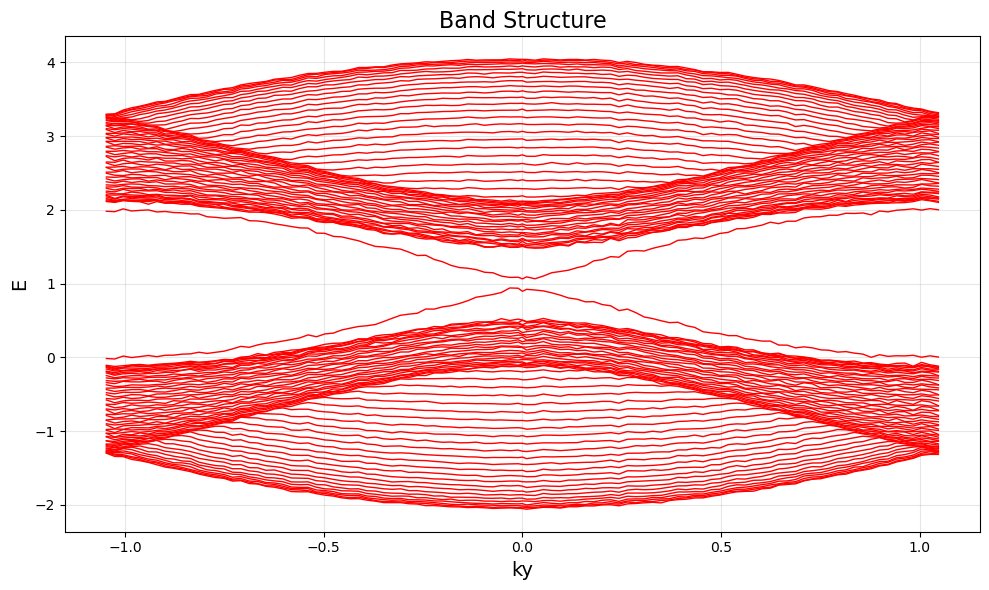

In [55]:
def plot_band_structure(ky_set, eigenvalues_all):
    plt.figure(figsize=(10, 6))
    
    for band_idx, band_energies in enumerate(eigenvalues_all):
        plt.plot(ky_set, band_energies, color='red', linewidth=1)
    
    plt.xlabel('ky', fontsize=14)
    plt.ylabel('E', fontsize=14)
    plt.title('Band Structure', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 参数设置
const = 1 
e = 1       # 能量参数
t = 1.0        # 跃迁强度
a = 1.0        # 晶格常数
shuzi = 50     # 控制矩阵大小，实际矩阵大小为 2*shuzi × 2*shuzi
ky_points = 100 # ky点的数量
zazhi=[-0.1,0.1]
# 计算并画能带
ky_set, eigenvalues_all = calculate_band_structure(const, e, t, a, shuzi, ky_points,zazhi)
plot_band_structure(ky_set, eigenvalues_all)

# 可选：打印一些信息
#print(f"矩阵大小: {2*shuzi} × {2*shuzi}")
#print(f"能带数量: {len(eigenvalues_all)}")
#print(f"每个能带的点数: {len(eigenvalues_all[0])}")

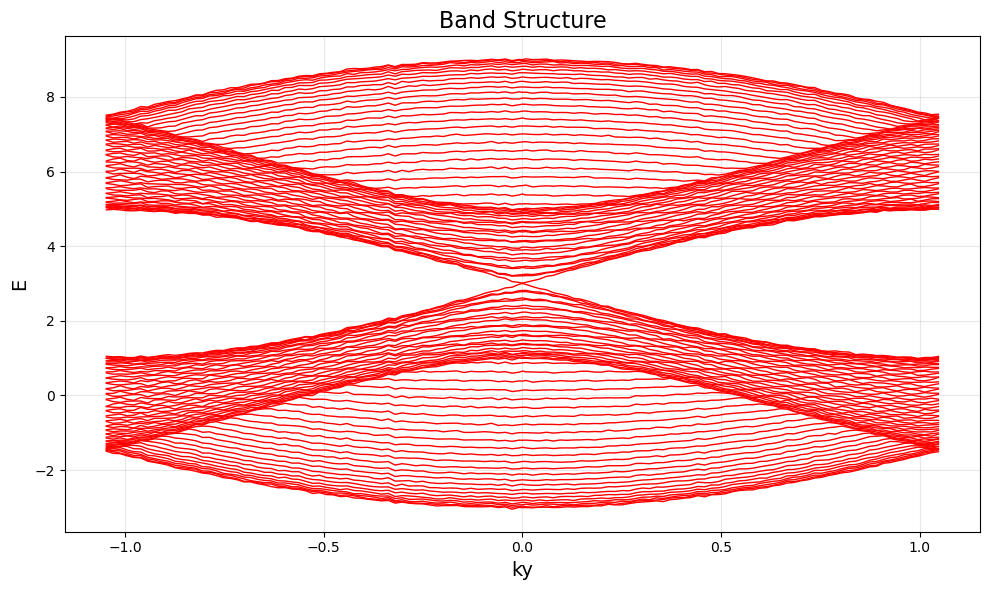

In [66]:
def save_band_data_to_excel(ky_set, eigenvalues_all, filename="band_structure.xlsx"):
    """
    将能带数据保存到Excel文件中
    
    参数:
    ky_set: k点数组
    eigenvalues_all: 能带数据列表
    filename: 保存的文件名
    """
    # 创建目录（如果不存在）
    save_dir = r"D:\结果\能带"
    os.makedirs(save_dir, exist_ok=True)
    
    # 完整文件路径
    file_path = os.path.join(save_dir, filename)
    
    # 创建数据字典
    data = {'ky': ky_set}
    
    # 添加每个能带的数据
    for band_idx in range(len(eigenvalues_all)):
        data[f'Band_{band_idx+1}'] = eigenvalues_all[band_idx]
    
    # 创建DataFrame
    df = pd.DataFrame(data)
    
    # 保存到Excel
    df.to_excel(file_path, index=False)

    return df

# 参数设置
const = 0#1+2j
e = 3       # 能量参数
t = 2.0      # 跃迁强度
a = 1.0        # 晶格常数
shuzi = 50     # 控制矩阵大小，实际矩阵大小为 2*shuzi × 2*shuzi
ky_points = 122 # ky点的数量
zazhi=[-0.2,0.2]

ky_set, eigenvalues_all = calculate_band_structure(const, e, t, a, shuzi, ky_points,zazhi)

plot_band_structure(ky_set, eigenvalues_all)
h=0
df = save_band_data_to_excel(ky_set, eigenvalues_all, f"band_data{h}.xlsx")

In [51]:
np.diag(np.random.uniform(-0.1, 0.1, 4))

array([[-0.03431465,  0.        ,  0.        ,  0.        ],
       [ 0.        , -0.0030137 ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.01447357,  0.        ],
       [ 0.        ,  0.        ,  0.        , -0.02642055]])